# Step 3 — Data Preprocessing, Applied EDA and Feature Engineering

**Capstone:** AI-Powered Household Energy Consumption Prediction and Monitoring System  
**Primary task:** Time-series regression  
**Target:** Next-day total household electricity consumption (kWh)

This notebook implements reproducible cleaning, applied exploratory analysis, leakage-safe feature engineering, feature selection, dimensionality reduction, and preliminary explainability. It produces chronological train, validation, and test datasets for Step 4.

## Decisions carried forward from Step 2

- 2,075,259 minute-level observations and seven measurement columns.
- 25,979 rows (1.2518%) have synchronized missing measurements.
- No duplicated or absent timestamps were detected.
- Nine days have no usable `Global_active_power` value.
- IQR-flagged peaks are retained because they may represent genuine high consumption.
- The first and last dates are partial days.

In [3]:
from pathlib import Path
import json
import platform
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import RobustScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Pandas: {pd.__version__}")

Python: 3.11.16
Platform: Windows-10-10.0.26200-SP0
Pandas: 2.3.3


## 1. Reproducible paths and configuration

The project root is detected whether the notebook is run from the repository root or the `notebooks` directory. All thresholds are stored in one configuration object and later saved as an artifact.

In [4]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "household_power_consumption.txt"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "random_state": RANDOM_STATE,
    "maximum_short_gap_minutes": 60,
    "minimum_daily_coverage": 0.95,
    "high_consumption_multiplier": 1.20,
    "high_consumption_window_days": 30,
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,
    "correlation_redundancy_threshold": 0.98,
    "selection_top_k": 15,
}

assert RAW_PATH.exists(), f"Raw dataset not found: {RAW_PATH}"
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(json.dumps(CONFIG, indent=2))

Project root: E:\My_Projects\AIM\capstone
{
  "random_state": 42,
  "maximum_short_gap_minutes": 60,
  "minimum_daily_coverage": 0.95,
  "high_consumption_multiplier": 1.2,
  "high_consumption_window_days": 30,
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "correlation_redundancy_threshold": 0.98,
  "selection_top_k": 15
}


## 2. Load and validate the raw data

The notebook reloads the raw file rather than depending on variables left in memory by Step 2. This makes Step 3 independently reproducible.

In [5]:
raw = pd.read_csv(RAW_PATH, sep=";", na_values=["?", ""], low_memory=False)
expected_columns = [
    "Date", "Time", "Global_active_power", "Global_reactive_power",
    "Voltage", "Global_intensity", "Sub_metering_1",
    "Sub_metering_2", "Sub_metering_3",
]
assert list(raw.columns) == expected_columns, "Unexpected raw-data schema."

raw["datetime"] = pd.to_datetime(
    raw["Date"].astype(str) + " " + raw["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S", errors="raise"
)
df = raw.drop(columns=["Date", "Time"]).set_index("datetime").sort_index()
df = df.apply(pd.to_numeric, errors="coerce")

assert not df.index.has_duplicates, "Duplicated timestamps require investigation."
assert df.index.is_monotonic_increasing
assert len(df) == 2_075_259, "Record count differs from the verified Step 2 result."
assert int(df.isna().any(axis=1).sum()) == 25_979, "Missing-row count changed."
display(df.head())
print(df.shape, df.index.min(), df.index.max())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
2006-12-16 17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
2006-12-16 17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


(2075259, 7) 2006-12-16 17:24:00 2010-11-26 21:02:00


## 3. Missing-value treatment

All seven measurements are absent in the same rows. Short gaps of at most 60 consecutive minutes are filled using time interpolation **only between observed values**. Longer gaps remain missing so the notebook does not manufacture extended consumption patterns.

The function first measures each missing run, then writes interpolated values only into eligible runs. This avoids partially filling the ends of long gaps.

In [6]:
def interpolate_short_gaps(series: pd.Series, maximum_gap: int = 60) -> pd.Series:
    missing = series.isna()
    run_id = missing.ne(missing.shift()).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    eligible = missing & run_length.le(maximum_gap)
    candidate = series.interpolate(method="time", limit_area="inside")
    result = series.copy()
    result.loc[eligible] = candidate.loc[eligible]
    return result


missing_before = df.isna().sum()
cleaned = df.apply(
    interpolate_short_gaps,
    maximum_gap=CONFIG["maximum_short_gap_minutes"]
)
missing_after = cleaned.isna().sum()

interpolation_summary = pd.DataFrame({
    "missing_before": missing_before,
    "values_interpolated": missing_before - missing_after,
    "missing_after": missing_after,
})
display(interpolation_summary)
interpolation_summary.to_csv(TABLES_DIR / "step3_interpolation_summary.csv")

,missing_before,values_interpolated,missing_after
Global_active_power,25979,288,25691
Global_reactive_power,25979,288,25691
Voltage,25979,288,25691
Global_intensity,25979,288,25691
Sub_metering_1,25979,288,25691
Sub_metering_2,25979,288,25691
Sub_metering_3,25979,288,25691


## 4. Duplicate and outlier policy

Step 2 found no duplicated timestamps, so no time-series records are removed as duplicates. Repeated measurement combinations are possible and valid because a household can exhibit the same measurements at different times.

IQR-flagged observations are retained. A high reading is not automatically an error; deleting peaks would weaken the system's ability to detect bill-shock-related consumption. Robust scaling will limit their influence on scale-sensitive models, while tree models require no scaling.

In [7]:
duplicate_timestamps = int(cleaned.index.duplicated(keep=False).sum())
negative_values = (cleaned < 0).sum()

policy_summary = pd.DataFrame({
    "check": ["Duplicated timestamps", "Negative measurement values", "Outlier removal"],
    "result": [duplicate_timestamps, int(negative_values.sum()), "None — genuine peaks retained"],
    "justification": [
        "No duplicate timestamps found in Step 2 or Step 3 validation",
        "Electrical measurements are expected to be non-negative",
        "Consumption spikes are relevant to high-use warning detection",
    ],
})
display(policy_summary)
assert duplicate_timestamps == 0
assert int(negative_values.sum()) == 0

,check,result,justification
0,Duplicated timestamps,0,No duplicate timestamps found in Step 2 or Ste...
1,Negative measurement values,0,Electrical measurements are expected to be non...
2,Outlier removal,None — genuine peaks retained,Consumption spikes are relevant to high-use wa...


## 5. Aggregate minute measurements into daily features

Original observation coverage is calculated before interpolation. A day is usable only when at least 95% of its 1,440 expected measurements were originally observed.

Daily energy is estimated from average active power:

$$\text{Daily kWh}=\text{mean active power in kW}\times24$$

This coverage-adjusted formulation avoids underestimating consumption when a small number of minutes is unavailable. Days below the coverage threshold remain missing and are never used as model targets.

In [8]:
original_coverage = df["Global_active_power"].resample("D").count().div(1440)

daily = pd.DataFrame(index=cleaned.resample("D").mean().index)
daily["coverage"] = original_coverage
daily["daily_energy_kwh"] = cleaned["Global_active_power"].resample("D").mean() * 24
daily["reactive_power_mean_kw"] = cleaned["Global_reactive_power"].resample("D").mean()
daily["voltage_mean_v"] = cleaned["Voltage"].resample("D").mean()
daily["voltage_std_v"] = cleaned["Voltage"].resample("D").std()
daily["intensity_mean_a"] = cleaned["Global_intensity"].resample("D").mean()
daily["sub_metering_1_kwh"] = cleaned["Sub_metering_1"].resample("D").sum(min_count=1) / 1000
daily["sub_metering_2_kwh"] = cleaned["Sub_metering_2"].resample("D").sum(min_count=1) / 1000
daily["sub_metering_3_kwh"] = cleaned["Sub_metering_3"].resample("D").sum(min_count=1) / 1000

usable_day = daily["coverage"].ge(CONFIG["minimum_daily_coverage"])
measurement_columns = daily.columns.drop("coverage")
daily.loc[~usable_day, measurement_columns] = np.nan
daily["is_usable_day"] = usable_day.astype(int)

daily_quality = pd.DataFrame({
    "measure": ["Calendar days", "Usable days", "Excluded low-coverage days", "Minimum required coverage"],
    "value": [len(daily), int(usable_day.sum()), int((~usable_day).sum()), CONFIG["minimum_daily_coverage"]],
})
display(daily_quality)
display(daily.describe().T)
daily.to_csv(PROCESSED_DIR / "daily_energy_cleaned.csv", index_label="date")
daily_quality.to_csv(TABLES_DIR / "step3_daily_quality.csv", index=False)

,measure,value
0,Calendar days,"1,442.0000"
1,Usable days,"1,417.0000"
2,Excluded low-coverage days,25.0000
3,Minimum required coverage,0.9500


,count,mean,std,min,25%,50%,75%,max
coverage,"1,442.0000",0.9869,0.1055,0.0000,1.0000,1.0000,1.0000,1.0000
daily_energy_kwh,"1,417.0000",26.1991,10.0026,4.1716,19.6623,25.9376,31.6750,79.5564
reactive_power_mean_kw,"1,417.0000",0.1237,0.0340,0.0578,0.0991,0.1189,0.1414,0.2902
voltage_mean_v,"1,417.0000",240.8409,2.0331,231.0882,240.0945,240.9737,241.8711,247.4350
voltage_std_v,"1,417.0000",2.4285,0.6928,1.0439,1.9089,2.3286,2.8953,5.9679
intensity_mean_a,"1,417.0000",4.6277,1.7252,0.8083,3.5128,4.5603,5.5353,14.0281
sub_metering_1_kwh,"1,417.0000",1.6147,1.5928,0.0000,0.6600,1.1180,2.2140,11.2240
sub_metering_2_kwh,"1,417.0000",1.8685,2.0963,0.0000,0.4310,0.6890,2.7405,12.1090
sub_metering_3_kwh,"1,417.0000",9.3044,3.6814,1.2880,6.7340,9.3100,11.7680,23.7430
is_usable_day,"1,442.0000",0.9827,0.1306,0.0000,1.0000,1.0000,1.0000,1.0000


## 6. Applied EDA — target distribution and time trend

The plots evaluate skew, extreme high-use days, long-term variation, and the usefulness of weekly and monthly smoothing. Only usable daily targets are shown.

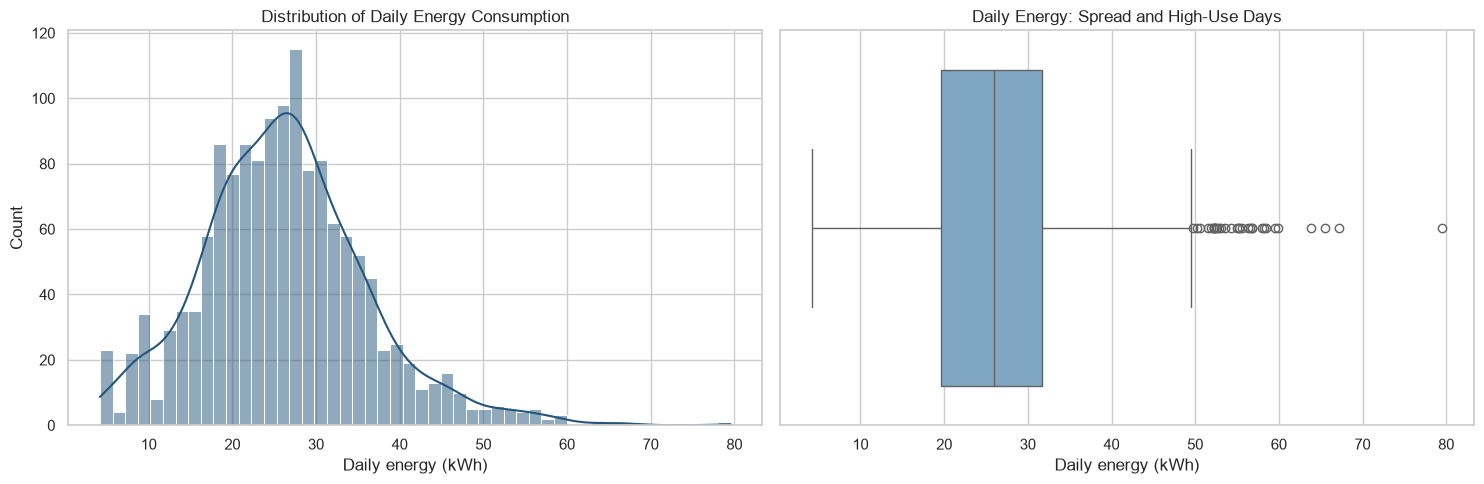

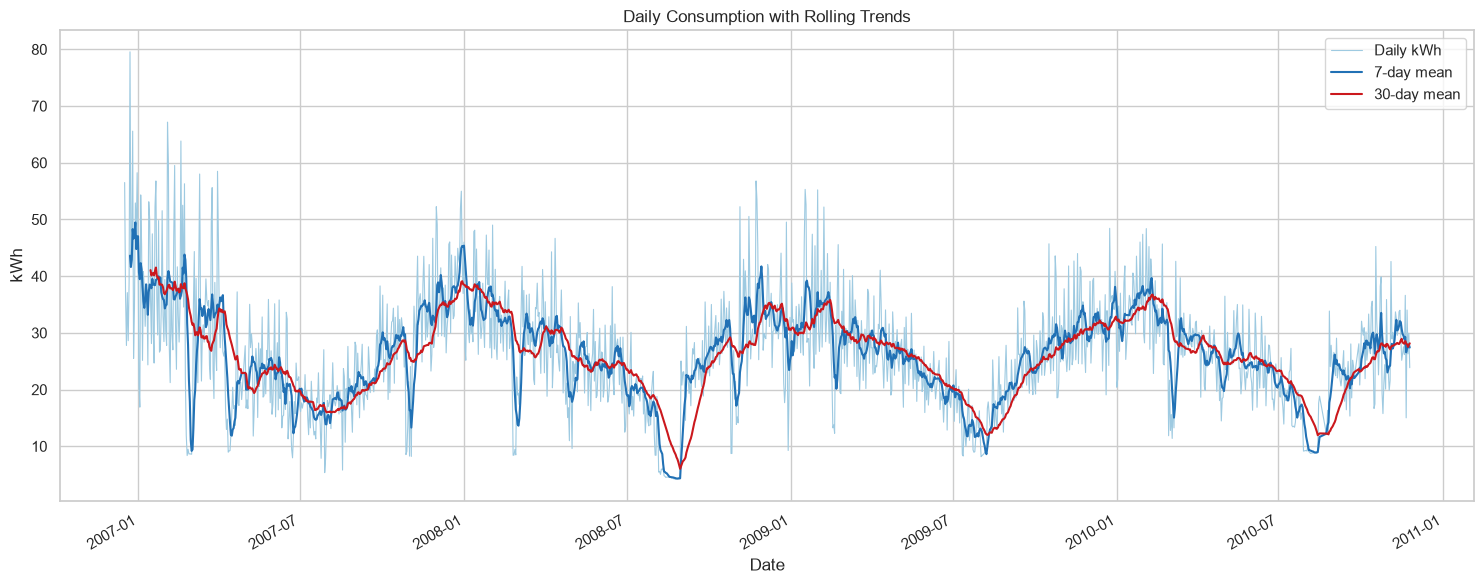

In [9]:
target_series = daily["daily_energy_kwh"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(target_series, bins=50, kde=True, ax=axes[0], color="#24557a")
axes[0].set(title="Distribution of Daily Energy Consumption", xlabel="Daily energy (kWh)")
sns.boxplot(x=target_series, ax=axes[1], color="#74a9cf")
axes[1].set(title="Daily Energy: Spread and High-Use Days", xlabel="Daily energy (kWh)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(15, 6))
target_series.plot(ax=ax, color="#9ecae1", linewidth=0.8, label="Daily kWh")
target_series.rolling(7).mean().plot(ax=ax, color="#2171b5", label="7-day mean")
target_series.rolling(30).mean().plot(ax=ax, color="#cb181d", label="30-day mean")
ax.set(title="Daily Consumption with Rolling Trends", xlabel="Date", ylabel="kWh")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_daily_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Applied EDA — calendar seasonality and autocorrelation

Day-of-week and month comparisons test domain expectations about routines and seasonal demand. Autocorrelation tests whether prior daily consumption is informative for forecasting.

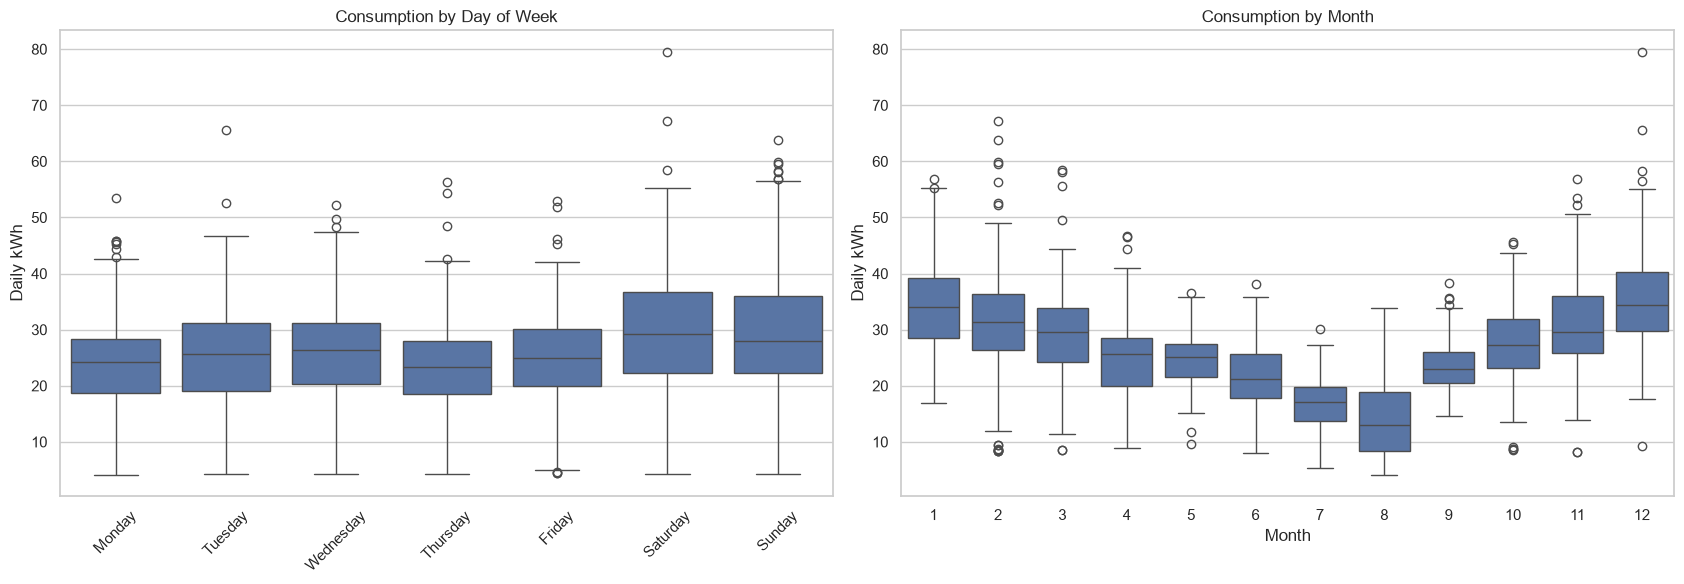

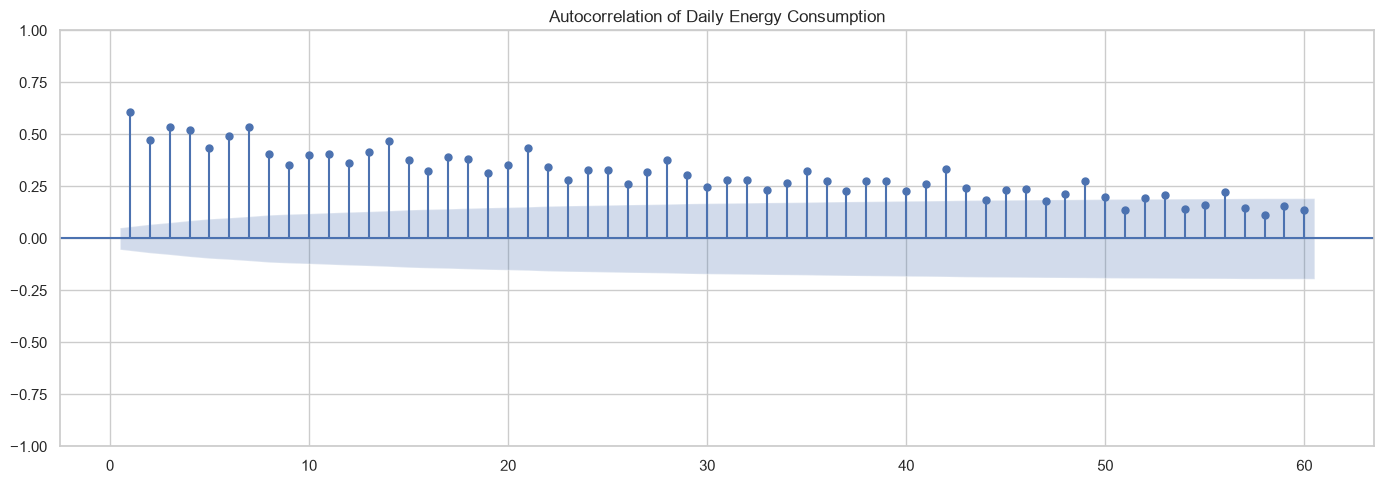

In [10]:
eda = target_series.to_frame()
eda["day_of_week"] = eda.index.day_name()
eda["month"] = eda.index.month
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.boxplot(data=eda, x="day_of_week", y="daily_energy_kwh", order=day_order, ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(title="Consumption by Day of Week", xlabel="", ylabel="Daily kWh")
sns.boxplot(data=eda, x="month", y="daily_energy_kwh", ax=axes[1])
axes[1].set(title="Consumption by Month", xlabel="Month", ylabel="Daily kWh")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_calendar_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(target_series, lags=60, zero=False, ax=ax)
ax.set_title("Autocorrelation of Daily Energy Consumption")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_target_autocorrelation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Leakage-safe feature engineering

Each row is indexed by the **day being predicted**. Every consumption-derived feature is shifted by at least one day, so only information available before the target day is used.

Domain features include:

- recent-use lags for persistence;
- seven-day lags for weekly routines;
- rolling means, variability, minima, and maxima;
- exponentially weighted trends;
- cyclic encodings for weekly and annual seasonality;
- prior-day electrical characteristics;
- a 30-day normal-use baseline and a 120% high-consumption threshold.

In [11]:
model_data = pd.DataFrame(index=daily.index)
model_data.index.name = "target_date"
model_data["target_daily_kwh"] = daily["daily_energy_kwh"]

for lag in [1, 2, 3, 7, 14, 21, 28, 30]:
    model_data[f"energy_lag_{lag}"] = daily["daily_energy_kwh"].shift(lag)

prior_measurements = [
    "reactive_power_mean_kw", "voltage_mean_v", "voltage_std_v",
    "intensity_mean_a", "sub_metering_1_kwh",
    "sub_metering_2_kwh", "sub_metering_3_kwh",
]
for column in prior_measurements:
    model_data[f"{column}_lag_1"] = daily[column].shift(1)

prior_energy = daily["daily_energy_kwh"].shift(1)
for window in [7, 14, 30]:
    rolling = prior_energy.rolling(window=window, min_periods=window)
    model_data[f"energy_roll_mean_{window}"] = rolling.mean()
    model_data[f"energy_roll_std_{window}"] = rolling.std()
    model_data[f"energy_roll_min_{window}"] = rolling.min()
    model_data[f"energy_roll_max_{window}"] = rolling.max()

model_data["energy_ewm_7"] = prior_energy.ewm(span=7, adjust=False).mean()
model_data["energy_ewm_30"] = prior_energy.ewm(span=30, adjust=False).mean()
model_data["energy_change_1d"] = daily["daily_energy_kwh"].shift(1) - daily["daily_energy_kwh"].shift(2)
model_data["energy_change_7d"] = daily["daily_energy_kwh"].shift(1) - daily["daily_energy_kwh"].shift(8)

model_data["day_of_week"] = model_data.index.dayofweek
model_data["month"] = model_data.index.month
model_data["day_of_year"] = model_data.index.dayofyear
model_data["is_weekend"] = (model_data.index.dayofweek >= 5).astype(int)
model_data["time_index"] = np.arange(len(model_data))
model_data["dow_sin"] = np.sin(2 * np.pi * model_data["day_of_week"] / 7)
model_data["dow_cos"] = np.cos(2 * np.pi * model_data["day_of_week"] / 7)
model_data["year_sin"] = np.sin(2 * np.pi * model_data["day_of_year"] / 365.25)
model_data["year_cos"] = np.cos(2 * np.pi * model_data["day_of_year"] / 365.25)

window = CONFIG["high_consumption_window_days"]
model_data["normal_use_30d_kwh"] = prior_energy.rolling(window, min_periods=window).mean()
model_data["high_consumption_threshold_kwh"] = (
    model_data["normal_use_30d_kwh"] * CONFIG["high_consumption_multiplier"]
)
model_data["actual_high_consumption"] = (
    model_data["target_daily_kwh"] > model_data["high_consumption_threshold_kwh"]
).astype(int)

metadata_columns = ["actual_high_consumption"]
feature_columns = [c for c in model_data.columns if c not in ["target_daily_kwh", *metadata_columns]]
modeling_dataset = model_data.dropna(subset=["target_daily_kwh", *feature_columns]).copy()

assert all("target" not in feature for feature in feature_columns)
assert modeling_dataset.index.is_monotonic_increasing
print(f"Complete modeling rows: {len(modeling_dataset):,}")
print(f"Candidate features: {len(feature_columns)}")
display(modeling_dataset.head())

Complete modeling rows: 1,147
Candidate features: 42


,target_daily_kwh,energy_lag_1,energy_lag_2,energy_lag_3,energy_lag_7,energy_lag_14,energy_lag_21,energy_lag_28,energy_lag_30,reactive_power_mean_kw_lag_1,voltage_mean_v_lag_1,voltage_std_v_lag_1,intensity_mean_a_lag_1,sub_metering_1_kwh_lag_1,sub_metering_2_kwh_lag_1,sub_metering_3_kwh_lag_1,energy_roll_mean_7,energy_roll_std_7,energy_roll_min_7,energy_roll_max_7,energy_roll_mean_14,energy_roll_std_14,energy_roll_min_14,energy_roll_max_14,energy_roll_mean_30,energy_roll_std_30,energy_roll_min_30,energy_roll_max_30,energy_ewm_7,energy_ewm_30,energy_change_1d,energy_change_7d,day_of_week,month,day_of_year,is_weekend,time_index,dow_sin,dow_cos,year_sin,year_cos,normal_use_30d_kwh,high_consumption_threshold_kwh,actual_high_consumption
target_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-01-16,28.1067,35.8113,50.1838,53.1136,31.1509,21.1539,65.5685,27.7699,56.5077,0.1214,241.2409,3.0978,6.2615,1.0990,2.2390,15.1630,38.3021,10.1541,24.3549,53.1136,36.3575,11.7758,16.9009,54.3235,41.0594,13.8992,16.9009,79.5564,39.9543,42.1804,-14.3725,-1.5447,1,1,16,0,31,0.7818,0.6235,0.2718,0.9624,41.0594,49.2713,0
2007-01-17,47.4615,28.1067,35.8113,50.1838,35.9133,16.9009,25.4793,37.0958,36.7304,0.1288,241.9448,2.7114,4.9760,2.0630,0.6440,6.5830,37.8672,10.5682,24.3549,53.1136,36.8541,11.2187,16.9009,54.3235,40.1127,13.7774,16.9009,79.5564,36.9924,41.2725,-7.7046,-3.0442,2,1,17,0,32,0.9749,-0.2225,0.2883,0.9575,40.1127,48.1352,0
2007-01-18,30.3577,47.4615,28.1067,35.8113,37.5866,54.3235,34.5440,28.6186,27.7699,0.1394,241.0052,2.7812,8.2839,3.5000,5.7370,16.0640,39.5169,11.1003,24.3549,53.1136,39.0370,9.9377,24.3549,54.3235,40.4704,13.8258,16.9009,79.5564,39.6097,41.6717,19.3547,11.5481,3,1,18,0,33,0.4339,-0.9010,0.3047,0.9524,40.4704,48.5645,0
2007-01-19,24.6740,30.3577,47.4615,28.1067,24.3549,45.2227,52.9065,39.0223,37.0958,0.1234,240.8936,2.6979,5.3425,0.0000,0.3360,13.4910,38.4842,11.6333,24.3549,53.1136,37.3252,9.1335,24.3549,53.1136,40.5567,13.7517,16.9009,79.5564,37.2967,40.9418,-17.1038,-7.2289,4,1,19,0,34,-0.4339,-0.9010,0.3211,0.9471,40.5567,48.6680,0
2007-01-20,52.2289,24.6740,30.3577,47.4615,53.1136,25.1396,46.7056,79.5564,28.6186,0.1181,240.1609,3.0050,4.3762,2.1030,0.3300,7.1720,38.5298,11.5692,24.6740,53.1136,35.8574,9.4136,24.3549,53.1136,40.1426,14.0434,16.9009,79.5564,34.1410,39.8923,-5.6837,0.3191,5,1,20,1,35,-0.9749,-0.2225,0.3373,0.9414,40.1426,48.1711,1


## 9. Feature relationships

The correlation view is applied to engineered predictors and the target. It supports feature selection but does not independently prove predictive value or causation.

,correlation_with_target
energy_ewm_7,0.6633
energy_roll_mean_7,0.6558
energy_roll_mean_14,0.6191
energy_ewm_30,0.6111
energy_lag_1,0.6087
energy_roll_max_7,0.6077
energy_roll_min_7,0.6060
intensity_mean_a_lag_1,0.6026
energy_roll_mean_30,0.5744
normal_use_30d_kwh,0.5744


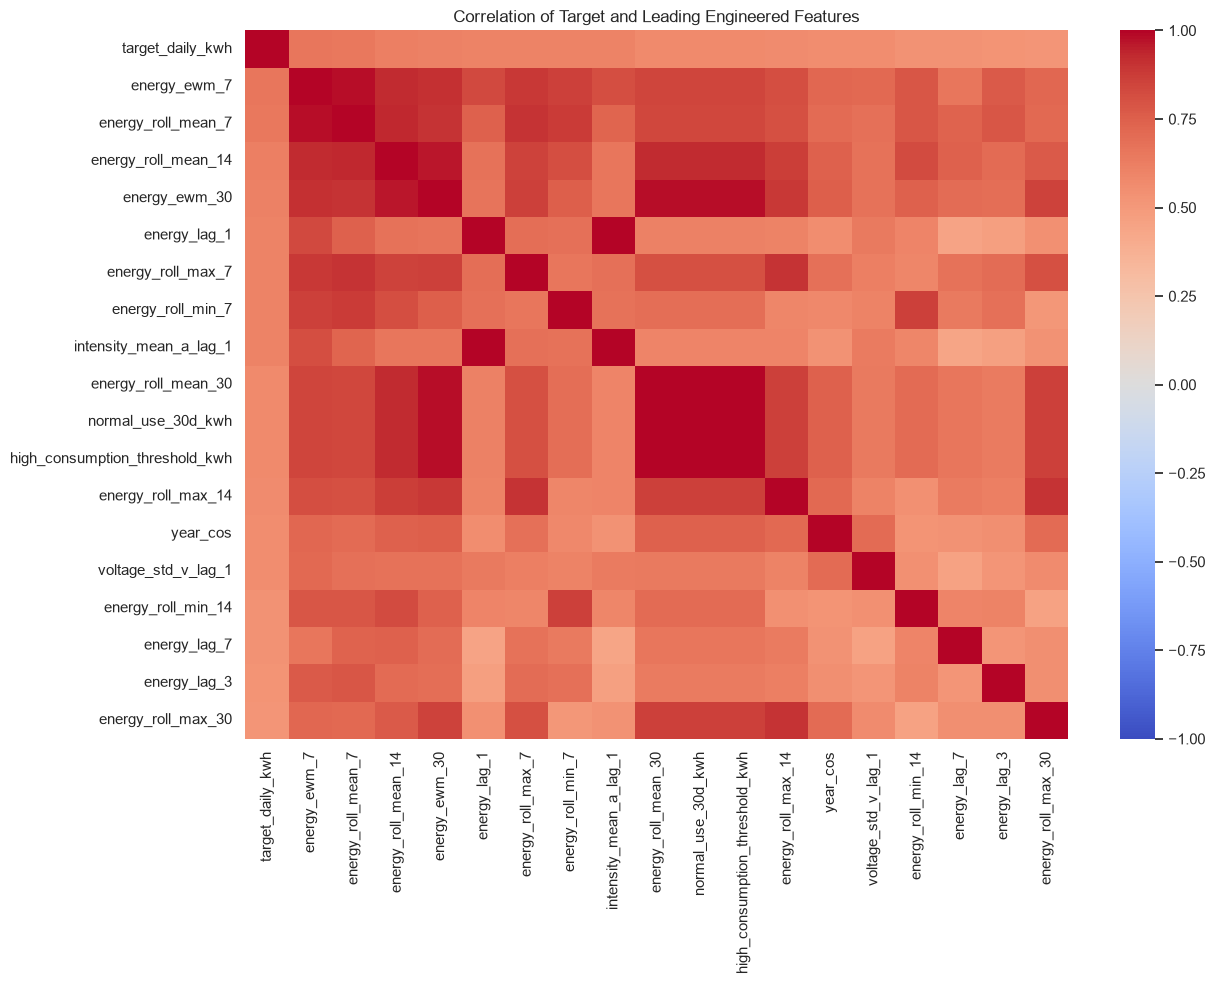

In [12]:
correlation = modeling_dataset[["target_daily_kwh", *feature_columns]].corr()
target_correlations = correlation["target_daily_kwh"].drop("target_daily_kwh").sort_values(key=abs, ascending=False)
display(target_correlations.to_frame("correlation_with_target"))
target_correlations.to_csv(TABLES_DIR / "step3_target_correlations.csv")

top_for_plot = target_correlations.head(18).index.tolist()
plt.figure(figsize=(13, 10))
sns.heatmap(
    modeling_dataset[["target_daily_kwh", *top_for_plot]].corr(),
    cmap="coolwarm", center=0, vmin=-1, vmax=1
)
plt.title("Correlation of Target and Leading Engineered Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_engineered_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Chronological train, validation, and test split

Feature selection, scaling, PCA, and preliminary modeling are fitted only on the earliest 70% training period. The next 15% is validation data, and the final 15% is held out for Step 4 testing. No rows are shuffled.

In [13]:
n_rows = len(modeling_dataset)
train_end = int(n_rows * CONFIG["train_fraction"])
validation_end = int(n_rows * (CONFIG["train_fraction"] + CONFIG["validation_fraction"]))

train = modeling_dataset.iloc[:train_end].copy()
validation = modeling_dataset.iloc[train_end:validation_end].copy()
test = modeling_dataset.iloc[validation_end:].copy()

X_train = train[feature_columns]
y_train = train["target_daily_kwh"]
X_validation = validation[feature_columns]
y_validation = validation["target_daily_kwh"]
X_test = test[feature_columns]
y_test = test["target_daily_kwh"]

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(train), len(validation), len(test)],
    "start": [train.index.min(), validation.index.min(), test.index.min()],
    "end": [train.index.max(), validation.index.max(), test.index.max()],
})
display(split_summary)
assert train.index.max() < validation.index.min() < test.index.min()
split_summary.to_csv(TABLES_DIR / "step3_split_summary.csv", index=False)

,split,rows,start,end
0,Train,802,2007-01-16,2009-05-30
1,Validation,172,2009-05-31,2010-02-23
2,Test,173,2010-02-24,2010-11-25


## 11. Feature selection

Three complementary approaches are used:

1. **Filter:** zero-variance and highly redundant predictors are removed using training data only.
2. **Filter/nonlinear:** mutual information ranks predictors that may have nonlinear relationships with consumption.
3. **Embedded:** Random Forest importance ranks predictors used by a preliminary nonlinear model.

The final set is the union of the top mutual-information and embedded features. This retains complementary signals while reducing weak or redundant inputs.

In [14]:
variance_filter = VarianceThreshold(threshold=0.0)
variance_filter.fit(X_train)
nonconstant_features = X_train.columns[variance_filter.get_support()].tolist()

train_corr = X_train[nonconstant_features].corr().abs()
upper = train_corr.where(np.triu(np.ones(train_corr.shape), k=1).astype(bool))
redundant_features = [
    column for column in upper.columns
    if any(upper[column] > CONFIG["correlation_redundancy_threshold"])
]
filtered_features = [f for f in nonconstant_features if f not in redundant_features]

mi_values = mutual_info_regression(
    X_train[filtered_features], y_train, random_state=RANDOM_STATE
)
mi_ranking = pd.Series(mi_values, index=filtered_features, name="mutual_information").sort_values(ascending=False)

preliminary_rf = RandomForestRegressor(
    n_estimators=400, min_samples_leaf=3, max_features=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
preliminary_rf.fit(X_train[filtered_features], y_train)
rf_ranking = pd.Series(
    preliminary_rf.feature_importances_, index=filtered_features,
    name="random_forest_importance"
).sort_values(ascending=False)

top_k = min(CONFIG["selection_top_k"], len(filtered_features))
selected_features = sorted(set(mi_ranking.head(top_k).index) | set(rf_ranking.head(top_k).index))

selection_table = pd.concat([mi_ranking, rf_ranking], axis=1).fillna(0)
selection_table["selected"] = selection_table.index.isin(selected_features)
display(selection_table.sort_values("random_forest_importance", ascending=False))
print("Removed redundant features:", redundant_features)
print(f"Final selected features ({len(selected_features)}):", selected_features)
selection_table.to_csv(TABLES_DIR / "step3_feature_selection.csv")

,mutual_information,random_forest_importance,selected
energy_ewm_7,0.2859,0.1767,True
energy_lag_1,0.3626,0.1314,True
energy_roll_mean_7,0.3088,0.0838,True
year_cos,0.3478,0.0550,True
energy_roll_min_7,0.3566,0.0488,True
energy_lag_7,0.2753,0.0388,True
energy_lag_14,0.2009,0.0331,True
energy_lag_21,0.1547,0.0270,True
dow_sin,0.0294,0.0241,True
energy_lag_28,0.1513,0.0233,True


Removed redundant features: ['intensity_mean_a_lag_1', 'energy_ewm_30', 'day_of_year', 'normal_use_30d_kwh', 'high_consumption_threshold_kwh']
Final selected features (22): ['day_of_week', 'dow_sin', 'energy_change_7d', 'energy_ewm_7', 'energy_lag_1', 'energy_lag_14', 'energy_lag_21', 'energy_lag_28', 'energy_lag_7', 'energy_roll_max_14', 'energy_roll_max_30', 'energy_roll_max_7', 'energy_roll_mean_14', 'energy_roll_mean_30', 'energy_roll_mean_7', 'energy_roll_min_14', 'energy_roll_min_30', 'energy_roll_min_7', 'month', 'time_index', 'voltage_std_v_lag_1', 'year_cos']


## 12. Preliminary model-based importance and SHAP explainability

The preliminary Random Forest is not the final Step 4 model. It is used here to evaluate whether engineered features contain useful signal and to explain their directional contribution. Permutation importance is calculated on validation data, while SHAP summarizes local contributions for a reproducible sample.

Preliminary validation MAE: 4.0651 kWh


,feature,importance_mean,importance_std
3,energy_ewm_7,0.5421,0.0726
4,energy_lag_1,0.4013,0.0751
21,year_cos,0.3815,0.0666
14,energy_roll_mean_7,0.2019,0.0460
1,dow_sin,0.1839,0.0776
0,day_of_week,0.1736,0.0884
10,energy_roll_max_30,0.1693,0.0338
6,energy_lag_21,0.1172,0.0358
17,energy_roll_min_7,0.0939,0.0268
7,energy_lag_28,0.0749,0.0323


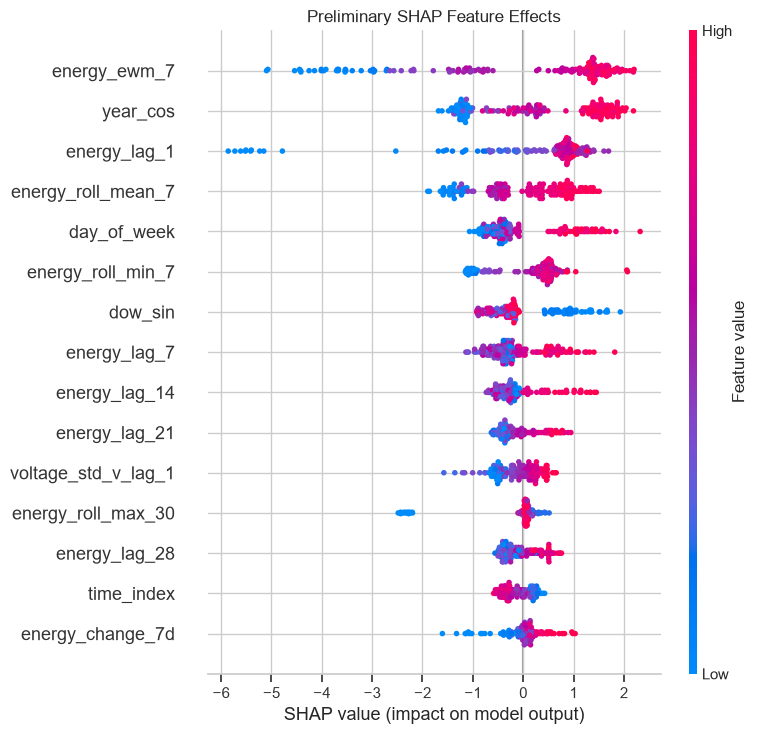

In [15]:
preliminary_selected_rf = RandomForestRegressor(
    n_estimators=400, min_samples_leaf=3, max_features=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
preliminary_selected_rf.fit(X_train[selected_features], y_train)
validation_prediction = preliminary_selected_rf.predict(X_validation[selected_features])
preliminary_mae = mean_absolute_error(y_validation, validation_prediction)
print(f"Preliminary validation MAE: {preliminary_mae:.4f} kWh")

perm = permutation_importance(
    preliminary_selected_rf, X_validation[selected_features], y_validation,
    scoring="neg_mean_absolute_error", n_repeats=20,
    random_state=RANDOM_STATE, n_jobs=-1
)
permutation_table = pd.DataFrame({
    "feature": selected_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
display(permutation_table)
permutation_table.to_csv(TABLES_DIR / "step3_permutation_importance.csv", index=False)

explain_sample = X_validation[selected_features].sample(
    n=min(300, len(X_validation)), random_state=RANDOM_STATE
)
explainer = shap.TreeExplainer(preliminary_selected_rf)
shap_values = explainer.shap_values(explain_sample)
shap.summary_plot(shap_values, explain_sample, show=False, max_display=15)
plt.title("Preliminary SHAP Feature Effects")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Scaling and PCA

`RobustScaler` is saved for scale-sensitive regression models because it uses medians and interquartile ranges. PCA uses standardized training predictors and is included for dimensionality analysis and visualization. PCA is not automatically selected for the final model because transformed components reduce direct feature interpretability.

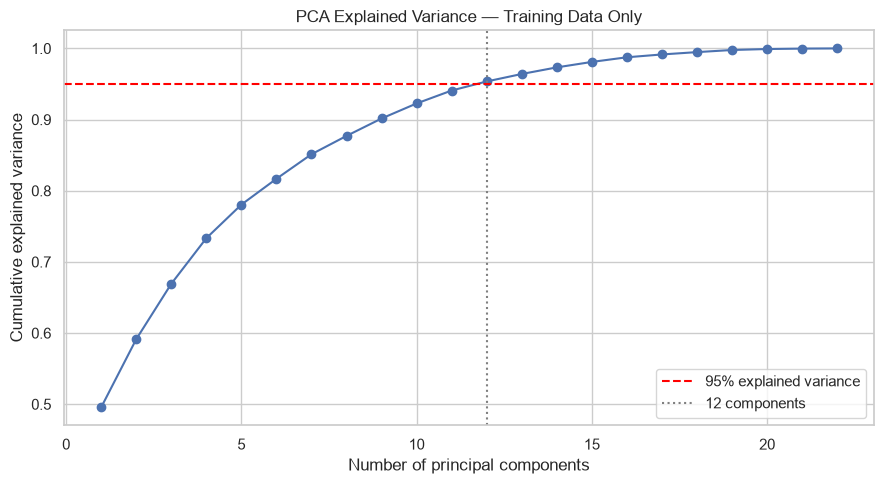

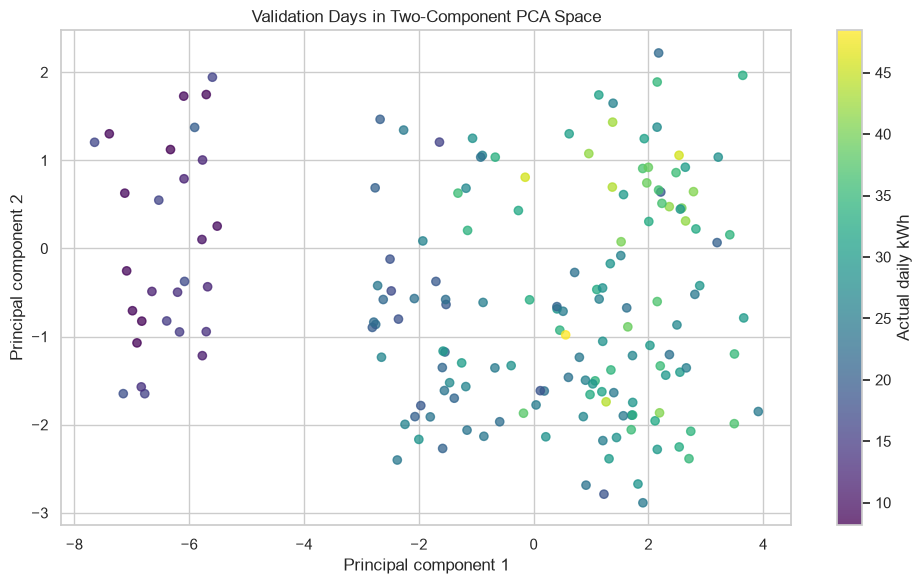

Components required for at least 95% training variance: 12


In [16]:
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train[selected_features])
X_validation_robust = robust_scaler.transform(X_validation[selected_features])
X_test_robust = robust_scaler.transform(X_test[selected_features])

pca_scaler = StandardScaler()
X_train_standard = pca_scaler.fit_transform(X_train[selected_features])
X_validation_standard = pca_scaler.transform(X_validation[selected_features])
X_test_standard = pca_scaler.transform(X_test[selected_features])

pca_all = PCA().fit(X_train_standard)
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% explained variance")
plt.axvline(components_95, color="gray", linestyle=":", label=f"{components_95} components")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance — Training Data Only")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_pca_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()

pca_95 = PCA(n_components=0.95).fit(X_train_standard)
pca_2 = PCA(n_components=2).fit(X_train_standard)
validation_2d = pca_2.transform(X_validation_standard)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    validation_2d[:, 0], validation_2d[:, 1],
    c=y_validation, cmap="viridis", alpha=0.75
)
plt.colorbar(scatter, label="Actual daily kWh")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Validation Days in Two-Component PCA Space")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_pca_validation_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Components required for at least 95% training variance: {components_95}")

## Interpretation of Step 3 findings

The daily target distribution is moderately right-skewed. Most days fall near
20–35 kWh, while a smaller number of genuine high-consumption days extend to
approximately 80 kWh. These observations were retained because they represent
the events that the monitoring component is designed to identify.

The time plot demonstrates substantial seasonal variation. Consumption is
generally higher during colder periods and lower around the middle of the year.
This pattern is also visible in the monthly boxplots and supports the inclusion
of annual sine and cosine features.

Weekend consumption is generally higher than weekday consumption, supporting
the inclusion of day-of-week, weekend and weekly cyclical features.

The autocorrelation plot shows persistent positive relationships across
multiple lags. Previous-day and weekly consumption therefore contain useful
forecasting information, supporting the lag, rolling-average and exponentially
weighted features.

The strongest correlations with next-day consumption came from recent
smoothed consumption, recent daily consumption and seasonal variables.
However, correlation was not used alone because it does not capture nonlinear
relationships.

Feature selection reduced 42 candidate features to 22 using only the training
period. Mutual information captured potentially nonlinear relationships, while
Random Forest importance captured embedded predictive contributions.

Permutation importance and SHAP both identified recent consumption and
seasonality as important. Some selected variables showed weak or negative
validation permutation importance and will be reconsidered during Step 4 model
comparison.

PCA required 12 components to preserve at least 95% of training variance.
Because principal components are less directly interpretable than the original
features, PCA will be evaluated as an optional representation for linear
models rather than automatically used by every model.

,category,count,percentage
0,Normal-consumption day,901,78.5527
1,High-consumption day,246,21.4473


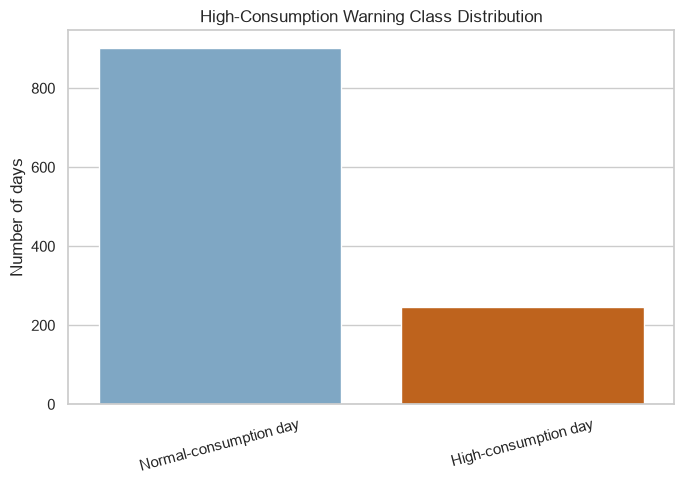

In [18]:
high_consumption_summary = pd.DataFrame(
    {
        "category": ["Normal-consumption day", "High-consumption day"],
        "count": [
            int((modeling_dataset["actual_high_consumption"] == 0).sum()),
            int((modeling_dataset["actual_high_consumption"] == 1).sum()),
        ],
    }
)

high_consumption_summary["percentage"] = (
    high_consumption_summary["count"]
    / high_consumption_summary["count"].sum()
    * 100
)

display(high_consumption_summary)

high_consumption_summary.to_csv(
    TABLES_DIR / "step3_high_consumption_summary.csv",
    index=False
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=high_consumption_summary,
    x="category",
    y="count",
    hue="category",
    palette=["#74a9cf", "#d95f02"],
    legend=False,
)

plt.title("High-Consumption Warning Class Distribution")
plt.xlabel("")
plt.ylabel("Number of days")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "step3_high_consumption_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 14. Save processed datasets and preprocessing artifacts

CSV files provide transparent inspection, while Parquet preserves datatypes efficiently. The fitted preprocessing objects, selected feature list, and configuration ensure Step 4 can reproduce exactly the same inputs.

In [19]:
def save_split(frame: pd.DataFrame, name: str) -> None:
    frame.to_csv(PROCESSED_DIR / f"{name}.csv", index_label="target_date")
    frame.to_parquet(PROCESSED_DIR / f"{name}.parquet", index=True)

modeling_dataset.to_csv(PROCESSED_DIR / "modeling_dataset.csv", index_label="target_date")
modeling_dataset.to_parquet(PROCESSED_DIR / "modeling_dataset.parquet", index=True)
save_split(train, "train")
save_split(validation, "validation")
save_split(test, "test")

artifacts = {
    "robust_scaler.joblib": robust_scaler,
    "pca_standard_scaler.joblib": pca_scaler,
    "pca_95.joblib": pca_95,
    "preliminary_random_forest.joblib": preliminary_selected_rf,
    "variance_filter.joblib": variance_filter,
}
for filename, artifact in artifacts.items():
    joblib.dump(artifact, MODELS_DIR / filename)

(MODELS_DIR / "selected_features.json").write_text(
    json.dumps(selected_features, indent=2), encoding="utf-8"
)
(MODELS_DIR / "step3_config.json").write_text(
    json.dumps(CONFIG, indent=2), encoding="utf-8"
)

artifact_manifest = sorted(
    str(path.relative_to(PROJECT_ROOT))
    for directory in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]
    for path in directory.glob("step3_*")
)
artifact_manifest += [
    str((MODELS_DIR / "selected_features.json").relative_to(PROJECT_ROOT)),
    str((PROCESSED_DIR / "modeling_dataset.parquet").relative_to(PROJECT_ROOT)),
]
print("Saved Step 3 artifacts:")
for item in sorted(set(artifact_manifest)):
    print(" -", item)

Saved Step 3 artifacts:
 - data\processed\modeling_dataset.parquet
 - models\selected_features.json
 - models\step3_config.json
 - outputs\figures\step3_calendar_seasonality.png
 - outputs\figures\step3_daily_trends.png
 - outputs\figures\step3_engineered_correlation.png
 - outputs\figures\step3_high_consumption_distribution.png
 - outputs\figures\step3_pca_explained_variance.png
 - outputs\figures\step3_pca_validation_projection.png
 - outputs\figures\step3_shap_summary.png
 - outputs\figures\step3_target_autocorrelation.png
 - outputs\figures\step3_target_distribution.png
 - outputs\tables\step3_daily_quality.csv
 - outputs\tables\step3_feature_selection.csv
 - outputs\tables\step3_high_consumption_summary.csv
 - outputs\tables\step3_interpolation_summary.csv
 - outputs\tables\step3_permutation_importance.csv
 - outputs\tables\step3_split_summary.csv
 - outputs\tables\step3_target_correlations.csv


## 15. Step 3 conclusions

- Missing values were handled conservatively: only short internal gaps were interpolated.
- Days below 95% original coverage were excluded from targets and predictors.
- No duplicate timestamps or invalid negative values required removal.
- High-use observations were retained because they are meaningful to the monitoring objective.
- EDA evaluated target distribution, temporal trends, weekly/monthly variation, autocorrelation, and engineered-feature relationships.
- Lag, rolling, calendar, cyclic, trend, electrical, and high-consumption features were derived using past information only.
- Feature selection combined variance, redundancy, mutual-information, and embedded approaches fitted only on training data.
- SHAP and permutation importance provided preliminary explainability.
- PCA was fitted on standardized training data and retained as an optional modeling representation.
- Chronological train, validation, and test datasets were saved for Step 4.

**Next step:** compare naïve baselines, Ridge Regression, Random Forest, and XGBoost using MAE, RMSE, MAPE, and R²; tune appropriate models with time-series cross-validation; evaluate high-consumption warnings; and save the final model and configuration.